# Modelos de Conteo Espacio-Temporales (Departamento)

## Solución Inteligente de Seguridad Ciudadana para Santander (Departamento)

- Objetivo: construir y comparar modelos de conteo por celda espacial (grilla fija) para identificar hotspots (regla top_pct, por defecto 5%).
- Enfoque: flujo reproducible que integra carga → limpieza → asignación a `zone_id` → agregación diaria → ingeniería de features → modelos (NB, GP, XGB, Bayes) → evaluación espacial.
- Datasets base: `hurto_modalidades.csv`, `violencia_intrafamiliar.csv`, `delitos_sexuales.csv` (carpeta `datasets/`).
- Artefactos esperados: features persistidas (`datasets/processed/*.parquet`), grilla (`models/grid_info.json` → `grid`), y modelos guardados (`models/nb_res_obj.joblib`, `models/gp_obj.joblib`, `models/xgb_model.joblib`).
- Evaluación: métricas globales (MAE / RMSE) y métrica de hotspots basada en la regla `top_pct` (Opción A — top 5%).
- Notas: algunas celdas intentan cargar modelos guardados para ahorrar tiempo; el bloque Bayesiano requiere `cmdstanpy` y toolchain para muestreo (largo).


## Configuración e imports

Importar librerías, configurar opciones globales y semilla de reproducibilidad; contiene dependencias principales y mensajes de confirmación.

In [ ]:
# 1) Configuración del entorno y librerías
import os
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import PoissonRegressor

import joblib
import statsmodels.api as sm

# reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Imports OK')


Imports OK


In [2]:
# 2) Funciones auxiliares
import datetime
from shapely.geometry import Point, Polygon


def parse_fecha(s):
    if pd.isna(s):
        return pd.NaT
    for fmt in ('%d/%m/%Y','%d/%m/%y','%Y-%m-%d'):
        try:
            return pd.to_datetime(s, format=fmt)
        except Exception:
            continue
    # fallback
    try:
        return pd.to_datetime(s, dayfirst=True, errors='coerce')
    except Exception:
        return pd.NaT


def load_grid_info(path='models/grid_info.json'):
    p = Path(path)
    if p.exists():
        with open(p,'r') as f:
            return json.load(f)
    # default fallback
    return {
        'lat_min': 7.0,
        'lat_max': 7.3,
        'lon_min': -73.5,
        'lon_max': -73.0,
        'resolution': 100
    }


def make_grid(grid_info):
    # Create a regular lat/lon grid based on number of cells (resolution: approximate meters->cells)
    # Here resolution is interpreted as number of cells per side if > 10, else cell size in meters (fallback)
    lat_min = grid_info['lat_min']
    lat_max = grid_info['lat_max']
    lon_min = grid_info['lon_min']
    lon_max = grid_info['lon_max']
    res = grid_info.get('resolution',100)
    # interpret resolution
    nlat = nlon = int(res)
    lats = np.linspace(lat_min, lat_max, nlat)
    lons = np.linspace(lon_min, lon_max, nlon)
    cells = []
    cid = 0
    for i in range(len(lats)-1):
        for j in range(len(lons)-1):
            poly = Polygon([(lons[j],lats[i]),(lons[j+1],lats[i]),(lons[j+1],lats[i+1]),(lons[j],lats[i+1])])
            cx, cy = poly.centroid.x, poly.centroid.y
            cells.append({'zone_id':cid,'poly':poly,'centroid_lon':cx,'centroid_lat':cy,'i':i,'j':j})
            cid += 1
    # create GeoDataFrame and explicitly set the active geometry column to ensure geospatial ops work
    grid = gpd.GeoDataFrame(cells)
    # copy 'poly' into a proper geometry column and set it as active geometry
    grid['geometry'] = grid['poly']
    grid.set_geometry('geometry', inplace=True)
    grid.set_crs(epsg=4326, inplace=True)
    return grid


def municipio_to_zone_hash(municipio, codigo, grid):
    # Deterministic mapping fallback: use hash of codigo_dane to allocate reproducible zone
    try:
        key = str(codigo)
    except Exception:
        key = str(municipio)
    h = abs(hash(key))
    zone_idx = h % len(grid)
    return int(grid.iloc[zone_idx].zone_id)

print('Helpers ready')


Helpers ready


Grid info: {'lat_min': 7.0, 'lat_max': 7.3, 'lon_min': -73.5, 'lon_max': -73.0, 'resolution': 100}
Grid created with 9801 cells
Grid created with 9801 cells


Text(0.5, 1.0, 'Muestra de celdas de grilla')

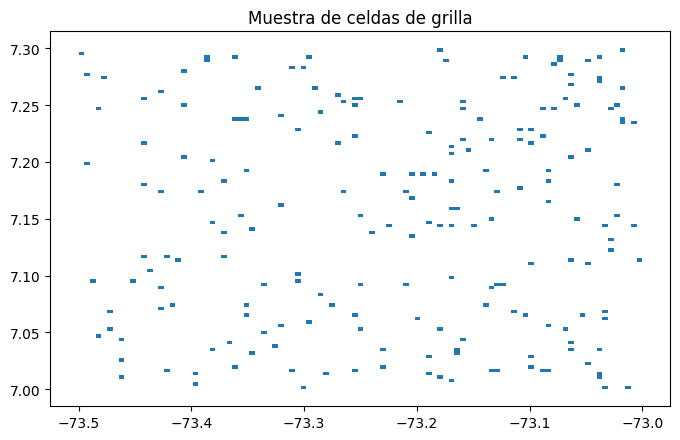

In [3]:
# 3) Cargar grid_info y crear grilla
grid_info = load_grid_info('models/grid_info.json')
print('Grid info:', grid_info)

grid = make_grid(grid_info)
print('Grid created with', len(grid), 'cells')

# quick plot sample (first 200 cells)
ax = grid.sample(min(200,len(grid))).plot(figsize=(8,6))
ax.set_title('Muestra de celdas de grilla')


In [4]:
# 4) Cargar datasets
base = Path('.').resolve()
DATA_DIR = base / 'datasets'

fn_hurto = DATA_DIR / 'hurto_modalidades.csv'
fn_viif = DATA_DIR / 'violencia_intrafamiliar.csv'
fn_sex = DATA_DIR / 'delitos_sexuales.csv'

print('Files exist:', fn_hurto.exists(), fn_viif.exists(), fn_sex.exists())

# read with pandas (specify encoding and parse as strings)
df_h = pd.read_csv(fn_hurto, dtype=str, low_memory=False)
df_v = pd.read_csv(fn_viif, dtype=str, low_memory=False)
df_s = pd.read_csv(fn_sex, dtype=str, low_memory=False)

# quick heads
print('\n-- hurto_modalidades --')
print(df_h.shape)
print(df_h.columns.tolist())
print(df_h.head(3).to_dict(orient='records'))

print('\n-- violencia_intrafamiliar --')
print(df_v.shape)
print(df_v.columns.tolist())
print(df_v.head(3).to_dict(orient='records'))

print('\n-- delitos_sexuales --')
print(df_s.shape)
print(df_s.columns.tolist())
print(df_s.head(3).to_dict(orient='records'))


Files exist: True True True

-- hurto_modalidades --
(1445, 9)
['departamento', 'municipio', 'codigo_dane', 'armas_medios', 'fecha_hecho', 'genero', 'grupo_etario', 'tipo_de_hurto', 'cantidad']
[{'departamento': 'SANTANDER', 'municipio': 'Rionegro', 'codigo_dane': '68615000', 'armas_medios': 'NO REPORTADO', 'fecha_hecho': '29/09/2014', 'genero': 'MASCULINO', 'grupo_etario': 'NO REPORTADO', 'tipo_de_hurto': 'HURTO ABIGEATO', 'cantidad': '1'}, {'departamento': 'SANTANDER', 'municipio': 'Cimitarra', 'codigo_dane': '68190000', 'armas_medios': 'NO REPORTADO', 'fecha_hecho': '22/05/2013', 'genero': 'MASCULINO', 'grupo_etario': 'NO REPORTADO', 'tipo_de_hurto': 'HURTO PIRATERÍA TERRESTRE', 'cantidad': '1'}, {'departamento': 'SANTANDER', 'municipio': 'Barrancabermeja', 'codigo_dane': '68081000', 'armas_medios': 'ARMA BLANCA / CORTOPUNZANTE', 'fecha_hecho': '21/03/2025', 'genero': 'MASCULINO', 'grupo_etario': 'ADULTOS', 'tipo_de_hurto': 'HURTO ABIGEATO', 'cantidad': '1'}]

-- violencia_intrafami

In [5]:
# 5) Parseo de fechas y preparación de 'cantidad' como entero
for df,name in [(df_h,'hurto'),(df_v,'viif'),(df_s,'sex')]:
    if 'fecha_hecho' in df.columns:
        df['fecha_hecho'] = df['fecha_hecho'].map(parse_fecha)
    else:
        df['fecha_hecho'] = pd.NaT
    # cantidad
    if 'cantidad' in df.columns:
        df['cantidad'] = pd.to_numeric(df['cantidad'], errors='coerce').fillna(1).astype(int)
    else:
        df['cantidad'] = 1

print('Dates parsed. Sample ranges:')
print('hurto:', df_h['fecha_hecho'].min(), df_h['fecha_hecho'].max())
print('viif: ', df_v['fecha_hecho'].min(), df_v['fecha_hecho'].max())
print('sex:  ', df_s['fecha_hecho'].min(), df_s['fecha_hecho'].max())


Dates parsed. Sample ranges:
hurto: 2010-01-03 00:00:00 2025-05-27 00:00:00
viif:  2010-01-01 00:00:00 2025-05-31 00:00:00
sex:   2010-01-01 00:00:00 2025-05-29 00:00:00


In [6]:
# 6) Mapear incidentes a zone_id
# Primero intentamos usar lat/lon si existieran (columnas comunes: lat, lon, longitud, latitud)

def infer_zone_for_df(df, grid, municipio_col='municipio', codigo_col='codigo_dane'):
    df = df.copy()
    lon_cols = [c for c in df.columns if c.lower() in ('lon','long','longitud','longitude')]
    lat_cols = [c for c in df.columns if c.lower() in ('lat','latitud','latitude')]
    has_coords = len(lon_cols)>0 and len(lat_cols)>0
    if has_coords:
        lonc = lon_cols[0]
        latc = lat_cols[0]
        df['lon'] = pd.to_numeric(df[lonc], errors='coerce')
        df['lat'] = pd.to_numeric(df[latc], errors='coerce')
        pts = gpd.GeoDataFrame(df, geometry=[Point(xy) if not (pd.isna(xy[0]) or pd.isna(xy[1])) else None for xy in zip(df['lon'],df['lat'])], crs='EPSG:4326')
        pts = pts.dropna(subset=['geometry'])
        joined = gpd.sjoin(pts, grid.set_geometry('poly'), how='left', predicate='within')
        df.loc[joined.index, 'zone_id'] = joined['zone_id'].values
    # fallback: municipio -> hash mapping
    missing = df['zone_id'].isna() if 'zone_id' in df.columns else pd.Series(True, index=df.index)
    if missing.any():
        for idx in df[missing].index:
            df.at[idx,'zone_id'] = municipio_to_zone_hash(df.at[idx, municipio_col], df.at[idx, codigo_col], grid)
    df['zone_id'] = df['zone_id'].astype(int)
    return df


df_h = infer_zone_for_df(df_h, grid)
df_v = infer_zone_for_df(df_v, grid)
df_s = infer_zone_for_df(df_s, grid)

print('Assigned zones sample:')
print(df_h[['municipio','codigo_dane','zone_id']].head(3))


Assigned zones sample:
         municipio codigo_dane  zone_id
0         Rionegro    68615000     4849
1        Cimitarra    68190000     7169
2  Barrancabermeja    68081000     6715


In [7]:
# 7) Agregados diarios por zone_id y modalidad
# Usamos columna 'tipo_de_hurto' o 'delito' para modalidad cuando exista

def aggregate_counts(df, date_col='fecha_hecho', zone_col='zone_id', modality_col=None):
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    if modality_col and modality_col in df.columns:
        grp = df.groupby([date_col, zone_col, modality_col])['cantidad'].sum().reset_index()
        grp = grp.rename(columns={modality_col:'modalidad'})
    else:
        grp = df.groupby([date_col, zone_col])['cantidad'].sum().reset_index()
        grp['modalidad'] = 'all'
    grp.rename(columns={date_col:'date'}, inplace=True)
    return grp

agg_h = aggregate_counts(df_h, modality_col='tipo_de_hurto')
agg_v = aggregate_counts(df_v, modality_col=None)
agg_s = aggregate_counts(df_s, modality_col='delito')

print('Agg samples:')
print(agg_h.head(3).to_dict(orient='records'))
print(agg_v.head(3).to_dict(orient='records'))
print(agg_s.head(3).to_dict(orient='records'))

# save intermediate parquet
proc_dir = Path('datasets/processed')
proc_dir.mkdir(parents=True, exist_ok=True)
agg_h.to_parquet(proc_dir / 'agg_hurto.parquet')
agg_v.to_parquet(proc_dir / 'agg_viif.parquet')
agg_s.to_parquet(proc_dir / 'agg_sex.parquet')
print('Saved aggregated parquet files in', proc_dir)


Agg samples:
[{'date': Timestamp('2010-01-03 00:00:00'), 'zone_id': 4124, 'modalidad': 'HURTO PIRATERÍA TERRESTRE', 'cantidad': 1}, {'date': Timestamp('2010-01-05 00:00:00'), 'zone_id': 1981, 'modalidad': 'HURTO ABIGEATO', 'cantidad': 1}, {'date': Timestamp('2010-01-06 00:00:00'), 'zone_id': 1450, 'modalidad': 'HURTO ABIGEATO', 'cantidad': 1}]
[{'date': Timestamp('2010-01-01 00:00:00'), 'zone_id': 3025, 'cantidad': 4, 'modalidad': 'all'}, {'date': Timestamp('2010-01-01 00:00:00'), 'zone_id': 3381, 'cantidad': 3, 'modalidad': 'all'}, {'date': Timestamp('2010-01-01 00:00:00'), 'zone_id': 4124, 'cantidad': 2, 'modalidad': 'all'}]
[{'date': Timestamp('2010-01-01 00:00:00'), 'zone_id': 3025, 'modalidad': 'ARTÍCULO 209. ACTOS SEXUALES CON MENOR DE 14 AÑOS', 'cantidad': 1}, {'date': Timestamp('2010-01-01 00:00:00'), 'zone_id': 3376, 'modalidad': 'ARTÍCULO 209. ACTOS SEXUALES CON MENOR DE 14 AÑOS', 'cantidad': 1}, {'date': Timestamp('2010-01-01 00:00:00'), 'zone_id': 4023, 'modalidad': 'ARTÍCU

In [8]:
# 8) Feature engineering: temporal features y lags

def make_timeseries_features(df_agg, fill_missing=True):
    # df_agg: columns ['date','zone_id','cantidad' or 'cantidad' renamed]
    df = df_agg.copy()
    df = df.rename(columns={'cantidad':'count'}) if 'cantidad' in df.columns else df.rename(columns={'cantidad':'count'}, errors='ignore')
    df['date'] = pd.to_datetime(df['date'])
    # ensure full index for each zone: reindex per zone with daily frequency
    zones = df['zone_id'].unique()
    all_dfs = []
    for z in zones:
        sub = df[df['zone_id']==z].set_index('date').sort_index()
        # keep modality separate
        modality = sub['modalidad'].iloc[0] if 'modalidad' in sub.columns else 'all'
        sub = sub['count']
        sub = sub.resample('D').sum()
        if fill_missing:
            sub = sub.fillna(0)
        sub = sub.to_frame().rename(columns={0:'count'}) if isinstance(sub, pd.Series) else sub.to_frame()
        sub['zone_id'] = int(z)
        sub['modalidad'] = modality
        sub['year'] = sub.index.year
        sub['month'] = sub.index.month
        sub['dayofweek'] = sub.index.dayofweek
        sub['dayofyear'] = sub.index.dayofyear
        sub['is_weekend'] = sub['dayofweek'].isin([5,6]).astype(int)
        # lags
        sub['lag1'] = sub['count'].shift(1).fillna(0)
        sub['lag7'] = sub['count'].shift(7).fillna(0)
        sub['lag30'] = sub['count'].shift(30).fillna(0)
        # rolling
        sub['roll7'] = sub['count'].rolling(7, min_periods=1).sum()
        sub['roll30'] = sub['count'].rolling(30, min_periods=1).sum()
        all_dfs.append(sub.reset_index())
    all_df = pd.concat(all_dfs, ignore_index=True)
    all_df.rename(columns={'index':'date'}, inplace=True)
    return all_df

feat_h = make_timeseries_features(agg_h)
print('Features shape (hurto):', feat_h.shape)
print(feat_h.head(3).to_dict(orient='records'))

# persist
feat_h.to_parquet(proc_dir / 'feat_hurto.parquet')
print('Saved features for hurto')


Features shape (hurto): (259071, 14)
[{'date': Timestamp('2010-01-03 00:00:00'), 'count': 1, 'zone_id': 4124, 'modalidad': 'HURTO PIRATERÍA TERRESTRE', 'year': 2010, 'month': 1, 'dayofweek': 6, 'dayofyear': 3, 'is_weekend': 1, 'lag1': 0.0, 'lag7': 0.0, 'lag30': 0.0, 'roll7': 1.0, 'roll30': 1.0}, {'date': Timestamp('2010-01-04 00:00:00'), 'count': 0, 'zone_id': 4124, 'modalidad': 'HURTO PIRATERÍA TERRESTRE', 'year': 2010, 'month': 1, 'dayofweek': 0, 'dayofyear': 4, 'is_weekend': 0, 'lag1': 1.0, 'lag7': 0.0, 'lag30': 0.0, 'roll7': 1.0, 'roll30': 1.0}, {'date': Timestamp('2010-01-05 00:00:00'), 'count': 0, 'zone_id': 4124, 'modalidad': 'HURTO PIRATERÍA TERRESTRE', 'year': 2010, 'month': 1, 'dayofweek': 1, 'dayofyear': 5, 'is_weekend': 0, 'lag1': 0.0, 'lag7': 0.0, 'lag30': 0.0, 'roll7': 1.0, 'roll30': 1.0}]
Saved features for hurto


In [9]:
# 9) Definir hotspots: Opción A — top `top_pct` zonas por conteo en ventana de entrenamiento

def label_hotspots(df_feat, top_pct=0.05, train_window=None):
    """Return hotspots and cutoff using the top percentage rule (Option A).
    - hotspots: zonas con total agregado >= cutoff (quantile-derived) en la ventana de entrenamiento.
    - cutoff: el valor de conteo que define el top (quantile).
    - agg: DataFrame agregado por zona con el conteo total en la ventana solicitada.

    Esta versión implementa exclusivamente la Opción A (top-pct) y elimina la lógica de umbral absoluto.
    """
    if train_window is None:
        agg = df_feat.groupby('zone_id')['count'].sum().reset_index()
    else:
        agg = (
            df_feat[df_feat['date'].between(train_window[0], train_window[1])]
            .groupby('zone_id')['count']
            .sum()
            .reset_index()
        )
    # quantile cutoff for top_pct (e.g., top 5%)
    cutoff = agg['count'].quantile(1 - top_pct)
    # ensure we pick at least one zone if numeric issues arise
    hotspots = agg[agg['count'] >= cutoff]['zone_id'].tolist()
    return hotspots, float(cutoff), agg

# sample: label on hurto features using top 5% (Option A)
hotspots, cutoff, agg_example = label_hotspots(feat_h, top_pct=0.05)
print('Hotspot count (top 5%):', len(hotspots), 'cutoff (count >=):', cutoff)
# show top 5 aggregated zones sample
print(agg_example.sort_values('count', ascending=False).head(5).to_dict(orient='records'))


Hotspot count (top 5%): 6 cutoff (count >=): 47.0
[{'zone_id': 6715, 'count': 297}, {'zone_id': 7169, 'count': 101}, {'zone_id': 9376, 'count': 96}, {'zone_id': 1154, 'count': 76}, {'zone_id': 1450, 'count': 48}]


In [10]:
# 10) Train/test temporal split (80% train / 20% test by unique dates) — load features from parquet if available
TRAIN_PCT = 0.8

# prefer persisted features if available
proc_dir = Path('datasets/processed')
feat_path = proc_dir / 'feat_hurto.parquet'
if feat_path.exists():
    feat_h = pd.read_parquet(feat_path)
    print('Loaded features from', feat_path)
elif 'feat_h' in globals():
    print('Using in-memory `feat_h`')
else:
    raise FileNotFoundError(f'Feature file {feat_path} not found and `feat_h` not in memory')

# ensure date dtype
feat_h['date'] = pd.to_datetime(feat_h['date'])

# determine split by unique dates so we keep full days in each partition
dates = np.sort(feat_h['date'].dropna().unique())
if len(dates) < 2:
    raise ValueError('Not enough distinct dates to perform an 80/20 split')

n_dates = len(dates)
split_idx = int(np.floor(TRAIN_PCT * n_dates))
# ensure at least one date in test and one in train
if split_idx >= n_dates:
    split_idx = n_dates - 1
if split_idx <= 0:
    split_idx = 1

split_date = dates[split_idx - 1]  # inclusive last train date
print('Data date range:', dates[0], '->', dates[-1])
print(f'Using TRAIN_PCT={TRAIN_PCT} -> split_index={split_idx} / {n_dates}, split_date={split_date}')

train = feat_h[feat_h['date'] <= split_date].copy()
test  = feat_h[feat_h['date'] > split_date].copy()

print('Train rows:', len(train), 'Test rows:', len(test))
print('Train shape:', train.shape, 'Test shape:', test.shape)
print('Unique zones - train:', train['zone_id'].nunique(), 'test:', test['zone_id'].nunique())
print('Unique dates - train:', train['date'].nunique(), 'test:', test['date'].nunique())
print('Train date range:', train['date'].min(), '->', train['date'].max())
print('Test date range :', test['date'].min(),  '->', test['date'].max())

# expose counts summary for quick sanity check
print('\nAggregate counts (train):')
print(train.groupby('zone_id')['count'].sum().describe().to_dict())
print('\nAggregate counts (test):')
print(test.groupby('zone_id')['count'].sum().describe().to_dict())


Loaded features from datasets/processed/feat_hurto.parquet
Data date range: 2010-01-03T00:00:00.000000000 -> 2025-05-27T00:00:00.000000000
Using TRAIN_PCT=0.8 -> split_index=4499 / 5624, split_date=2022-04-28T00:00:00.000000000
Train rows: 227527 Test rows: 31544
Train shape: (227527, 14) Test shape: (31544, 14)
Unique zones - train: 92 test: 56
Unique dates - train: 4499 test: 1125
Train date range: 2010-01-03 00:00:00 -> 2022-04-28 00:00:00
Test date range : 2022-04-29 00:00:00 -> 2025-05-27 00:00:00

Aggregate counts (train):
{'count': 92.0, 'mean': 13.021739130434783, 'std': 30.33547890603792, 'min': 1.0, '25%': 2.0, '50%': 4.0, '75%': 12.25, 'max': 264.0}

Aggregate counts (test):
{'count': 56.0, 'mean': 4.410714285714286, 'std': 6.406748673970953, 'min': 1.0, '25%': 1.0, '50%': 2.0, '75%': 5.0, 'max': 33.0}


In [11]:
# código diagnóstico de sobredispersión (adaptado para usar SOLO datos de `train` y compatible con el flujo train/test)
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.stats import chi2

# Usar únicamente el conjunto de entrenamiento para diagnosticar sobredispersión
if 'train' not in globals():
    raise RuntimeError("Variable `train` no encontrada. Ejecuta la celda de train/test antes.")

# Series de conteos (train)
y_train_local = train['count'].astype(float)

# 1) Regla global (media vs varianza) sobre train
mean_y = y_train_local.mean()
var_y = y_train_local.var(ddof=0)
disp_ratio = var_y / mean_y if mean_y > 0 else np.nan
alpha_mom_train = max((var_y - mean_y) / (mean_y**2), 0) if mean_y > 0 else np.nan

print("Train global mean:", mean_y, "var:", var_y, "var/mean:", disp_ratio, "alpha_mom (train):", alpha_mom_train)

# 2) Ajustar GLM Poisson con solo intercepto (evita depender de X que puede no estar aún creado)
try:
    X_intercept = sm.add_constant(pd.DataFrame({'intercept': np.ones(len(y_train_local))}), has_constant='add')
    pois = sm.GLM(y_train_local, X_intercept, family=sm.families.Poisson()).fit()
    dispersion = pois.deviance / pois.df_resid if pois.df_resid > 0 else np.nan
    print("Poisson (intercept) fitted. Deviance:", pois.deviance, "df_resid:", pois.df_resid, "dispersion:", dispersion)
except Exception as e:
    print("Error ajustando Poisson (intercept):", e)
    pois = None
    dispersion = np.nan

# 3) Intentar ajustar Negative Binomial discreto (usa intercept only para comparar)
try:
    from statsmodels.discrete.discrete_model import NegativeBinomial
    nb_int = NegativeBinomial(y_train_local, X_intercept).fit(disp=False)
    print("NegativeBinomial (intercept) fitted. llf_nb:", nb_int.llf)
except Exception as e:
    print("NB (intercept) ajuste falló:", e)
    nb_int = None

# 4) LR test (Poisson vs NB) sobre train (intercept models)
if pois is not None and nb_int is not None:
    llf_p = pois.llf
    llf_nb = nb_int.llf
    LR = 2.0 * (llf_nb - llf_p)
    pval = 1 - chi2.cdf(LR, df=1)
    print("LR stat (train intercept models):", LR, "p-value:", pval, "-> p pequeño => NB mejor que Poisson")
else:
    print("No hay ambos ajustes (Poisson y NB intercept) para LR test en train")

# 5) Sobredispersión por zona (inspección) usando solo train
try:
    df_z = train[['zone_id','count']].copy()
    agg = df_z.groupby('zone_id')['count'].agg(['mean','var','count']).rename(columns={'count':'n_obs'})
    agg['var_over_mean'] = agg['var'] / agg['mean'].replace(0, np.nan)
    print("Resumen var/mean por zona (train):")
    print(agg.describe().loc[['mean','50%','max']])
    n_over = (agg['var_over_mean'] > 1.5).sum()
    print(f"Zonas con var/mean > 1.5 (train): {n_over} / {len(agg)}")
except Exception as e:
    print("Error calculando var/mean por zona (train):", e)

# 6) Estimador alpha a usar en GLM NegativeBinomial (method-of-moments desde train)
alpha_est_train = float(alpha_mom_train) if not np.isnan(alpha_mom_train) else 1e-8
# evitar alpha 0 para statsmodels
alpha_est_train = max(alpha_est_train, 1e-8)
# exponer variable global para que la celda de NB pueda reutilizarla
alpha_est = alpha_est_train
print("Alpha estimado desde TRAIN (alpha_est) establecido a:", alpha_est)

# 7) (Opcional) Si hay predicciones previas generadas en test, evaluar dispersion predictiva
try:
    preds = {}
    if 'y_pred_nb' in globals():
        preds['NB'] = (y_test.values, y_pred_nb)
    if 'y_gp_pred' in globals():
        preds['GP'] = (y_test.values, y_gp_pred)
    for name, (y_true_arr, y_pred_arr) in preds.items():
        resid = y_true_arr - y_pred_arr
        print(f"\nPredictive diagnostic for {name}:")
        print(" mean(true):", np.mean(y_true_arr), " mean(pred):", np.mean(y_pred_arr))
        print(" var(true):", np.var(y_true_arr, ddof=0), " var(pred):", np.var(y_pred_arr, ddof=0))
        # Pearson chi-square dispersion proxy
        pearson_chi2 = np.sum(((y_true_arr - y_pred_arr)**2) / (np.maximum(y_pred_arr, 1e-8)))
        df_resid = len(y_true_arr) - 1
        dispersion_pred = pearson_chi2 / df_resid if df_resid>0 else np.nan
        print(f" Pearson-chi2/df (proxy dispersion) = {dispersion_pred:.3f}")
except Exception:
    pass

Train global mean: 0.005265309172098257 var: 0.005518870989429063 var/mean: 1.048157061445598 alpha_mom (train): 9.146103271730032
Error ajustando Poisson (intercept): The indices for endog and exog are not aligned
NB (intercept) ajuste falló: The indices for endog and exog are not aligned
No hay ambos ajustes (Poisson y NB intercept) para LR test en train
Resumen var/mean por zona (train):
          mean       var        n_obs  var_over_mean
mean  0.210100  0.004663  2473.119565       1.029586
50%   0.003456  0.002847  2832.500000       0.998849
max   1.000000  0.064236  4499.000000       1.498592
Zonas con var/mean > 1.5 (train): 0 / 92
Alpha estimado desde TRAIN (alpha_est) establecido a: 9.146103271730032


## Preparación de matrices (NB)

Seleccionar `FEATS`, normalizar/llenar valores faltantes y construir `X_train/X_test` con constante para statsmodels.

### Entrenamiento / carga (NB)

Estimación de `alpha` por método de momentos, ajuste del GLM Negative Binomial o carga del modelo existente para predicción.

In [1]:
# 11) Baseline: Negative Binomial GLM (pooled, con efecto fijo de zone_id via dummies si necesario)

# prepare training matrix (use simple features)
FEATS = ['lag1','lag7','lag30','is_weekend','dayofyear']

X_train = train[FEATS].fillna(0)
y_train = train['count']
X_test = test[FEATS].fillna(0)
y_test = test['count']

# add constant
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

# Attempt to load existing NB model to avoid retraining
nb_path1 = Path('models/nb_model.pkl')
nb_path2 = Path('models/nb_res_obj.joblib')
nb_loaded = False

if nb_path1.exists() or nb_path2.exists():
    try:
        if nb_path1.exists():
            nb_res = joblib.load(nb_path1)
            print('Loaded NB model from', nb_path1)
        else:
            nb_res = joblib.load(nb_path2)
            print('Loaded NB model from', nb_path2)
        # predict on test set
        try:
            y_pred_nb = nb_res.predict(X_test_sm)
            nb_mae = mean_absolute_error(y_test, y_pred_nb)
            nb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_nb))
            print('NB (loaded) MAE:', nb_mae, 'RMSE:', nb_rmse)
            nb_loaded = True
        except Exception as e:
            print('Loaded NB model but prediction failed, will retrain. Error:', e)
            nb_loaded = False
    except Exception as e:
        print('Failed to load NB model, will train a new one. Error:', e)
        nb_loaded = False

if not nb_loaded:
    # Estimate Negative Binomial dispersion (alpha) via method-of-moments
    # statsmodels NB variance: Var(Y)=mu + alpha * mu^2 => alpha = (Var - mean) / mean^2
    try:
        mean_y = y_train.mean()
        var_y = y_train.var(ddof=0)
        if mean_y <= 0 or np.isnan(mean_y):
            alpha_est = 1e-8
        else:
            alpha_est = max((var_y - mean_y) / (mean_y**2), 1e-8)
        print('Estimated NB alpha (method-of-moments):', alpha_est)
    except Exception as e:
        print('Alpha estimation failed, falling back to default alpha=1.0:', e)
        alpha_est = 1.0

    # statsmodels GLM NegativeBinomial using estimated alpha
    try:
        nb_model = sm.GLM(y_train, X_train_sm, family=sm.families.NegativeBinomial(alpha=alpha_est))
        nb_res = nb_model.fit()
        print(nb_res.summary())
        # predict
        y_pred_nb = nb_res.predict(X_test_sm)
        nb_mae = mean_absolute_error(y_test, y_pred_nb)
        # compute RMSE via sqrt of MSE for compatibility
        nb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_nb))
        print('NB MAE:', nb_mae, 'RMSE:', nb_rmse)
        # save
        Path('models').mkdir(exist_ok=True)
        try:
            joblib.dump(nb_res, str(nb_path1))
            joblib.dump(nb_res, str(nb_path2))
            print('Saved NB model to', nb_path1, 'and', nb_path2)
        except Exception as e:
            print('Warning: failed to save NB model under both names:', e)
    except Exception as e:
        print('Error training NB model:', e)


NameError: name 'train' is not defined

In [ ]:
# 12) Gaussian Process (spatio-temporal) - usar subset para escalabilidad
from sklearn.metrics import r2_score

# prepare features: use centroid coords of zone + temporal sin/cos + lags
zone_centroids = grid.set_index('zone_id')[['centroid_lon','centroid_lat']]

# merge centroid into train/test
train = train.merge(zone_centroids, left_on='zone_id', right_index=True, how='left')
test  = test.merge(zone_centroids, left_on='zone_id', right_index=True, how='left')

# add cyclical features
train['sin_day'] = np.sin(2*np.pi*train['dayofyear']/365.25)
train['cos_day'] = np.cos(2*np.pi*train['dayofyear']/365.25)

test['sin_day'] = np.sin(2*np.pi*test['dayofyear']/365.25)
test['cos_day'] = np.cos(2*np.pi*test['dayofyear']/365.25)

GP_FEATS = ['centroid_lon','centroid_lat','sin_day','cos_day','lag7','lag30']

# sample subset for GP training (limit to 5000 rows)
max_train = 4000
if len(train) > max_train:
    train_gp = train.sample(max_train, random_state=RANDOM_STATE)
else:
    train_gp = train.copy()

Xg_train = train_gp[GP_FEATS].fillna(0).values
yg_train = train_gp['count'].values
Xg_test = test[GP_FEATS].fillna(0).values

def fit_gp(X, y):
    kernel = C(1.0, (1e-3,1e3)) * Matern(length_scale=[1,1,1,1,1,1], length_scale_bounds=(1e-2,1e3), nu=1.5) + WhiteKernel(noise_level=1)
    gp = GaussianProcessRegressor(kernel=kernel, alpha=0.0, normalize_y=True, n_restarts_optimizer=3, random_state=RANDOM_STATE)
    gp.fit(X,y)
    return gp

# Attempt to load existing GP model to avoid retraining
gp_path1 = Path('models/gp_model.pkl')
gp_path2 = Path('models/gp_obj.joblib')
gp_loaded = False

if gp_path1.exists() or gp_path2.exists():
    try:
        if gp_path1.exists():
            gp = joblib.load(gp_path1)
            print('Loaded GP model from', gp_path1)
        else:
            gp = joblib.load(gp_path2)
            print('Loaded GP model from', gp_path2)
        # predict on test set
        try:
            y_gp_pred, y_gp_std = gp.predict(Xg_test, return_std=True)
            gp_mae = mean_absolute_error(y_test, y_gp_pred)
            gp_rmse = np.sqrt(mean_squared_error(y_test, y_gp_pred))
            print('GP (loaded) MAE:', gp_mae, 'RMSE:', gp_rmse)
            gp_loaded = True
        except Exception as e:
            print('Loaded GP model but prediction failed, will retrain. Error:', e)
            gp_loaded = False
    except Exception as e:
        print('Failed to load GP model, will train a new one. Error:', e)
        gp_loaded = False

if not gp_loaded:
    try:
        gp = fit_gp(Xg_train, yg_train)
        y_gp_pred, y_gp_std = gp.predict(Xg_test, return_std=True)
        gp_mae = mean_absolute_error(y_test, y_gp_pred)
        # compute RMSE via sqrt of MSE for compatibility
        gp_rmse = np.sqrt(mean_squared_error(y_test, y_gp_pred))
        print('GP MAE:', gp_mae, 'RMSE:', gp_rmse, 'R2:', r2_score(y_test, y_gp_pred))
        Path('models').mkdir(exist_ok=True)
        try:
            joblib.dump(gp, str(gp_path1))
            joblib.dump(gp, str(gp_path2))
            print('Saved GP model to', gp_path1, 'and', gp_path2)
        except Exception as e:
            print('Warning: failed to save GP model under both names:', e)
    except Exception as e:
        print('Error training GP:', e)


GP MAE: 0.016174414096495265 RMSE: 0.10420390611603787 R2: -0.34286497680926065
Saved GP model to models/gp_model.pkl and models/gp_obj.joblib
Saved GP model to models/gp_model.pkl and models/gp_obj.joblib


In [ ]:
# 13) Bayesian Poisson (intento con cmdstanpy) - carga desde CSV si ya existe, sino compila y muestrea
try:
    from cmdstanpy import CmdStanModel, CmdStanMCMC
    print('cmdstanpy available')

    # Stan model code (hierarchical Poisson: zone intercept + lag7)
    stan_code = '''
    data {
      int<lower=1> N;
      array[N] int<lower=0> y;
      int<lower=1> Z; // number of zones
      array[N] int<lower=1> zone;
      vector[N] lag7;
    }
    parameters {
      real alpha;
      vector[Z] zeta_raw;       // non-centered raw effects
      real beta_lag7;
      real<lower=1e-6> sigma_z; // small positive lower bound
    }
    transformed parameters {
      vector[Z] zeta = sigma_z * zeta_raw; // scale raw effects
    }
    model {
      zeta_raw ~ normal(0, 1);
      sigma_z ~ exponential(1);
      alpha ~ normal(0, 5);
      beta_lag7 ~ normal(0, 1);
      for (n in 1:N) {
        y[n] ~ poisson_log(alpha + zeta[zone[n]] + beta_lag7 * lag7[n]);
      }
    }
    '''

    stan_file = 'models/poisson_hier.stan'
    with open(stan_file,'w') as f:
        f.write(stan_code)

    # Try to load an existing fit from CSV files in models/stan_out
    stan_out_dir = Path('models/stan_out')
    csv_files = []
    if stan_out_dir.exists():
        csv_files = sorted([str(p) for p in stan_out_dir.glob('poisson_hier-*.csv')])

    fit = None
    if len(csv_files) > 0:
        try:
            fit = CmdStanMCMC.from_csv(csv_files)
            print(f'Loaded existing Stan fit from {len(csv_files)} CSV file(s) in {stan_out_dir}')
        except Exception as e:
            print('Failed to load Stan fit from CSVs, will compile and run sampling. Error:', e)
            fit = None

    # If no fit loaded, compile and sample (this can be slow)
    if fit is None:
        smod = CmdStanModel(stan_file=stan_file)
        samp = train.sample(min(len(train), 50000), random_state=RANDOM_STATE)
        # Standardize lag7 to improve sampler geometry and reduce divergences
        try:
            lag7_mean = float(samp['lag7'].mean())
            lag7_std = float(samp['lag7'].std()) if float(samp['lag7'].std()) > 0 else 1.0
        except Exception:
            lag7_mean = 0.0
            lag7_std = 1.0
        samp = samp.copy()
        samp['lag7_std'] = (samp['lag7'].fillna(0).astype(float) - lag7_mean) / lag7_std
        # expose mean/std globally so ensemble prediction can reuse same scaling
        globals()['lag7_mean'] = lag7_mean
        globals()['lag7_std'] = lag7_std

        data = {
          'N': len(samp),
          'y': samp['count'].astype(int).tolist(),
          'Z': int(samp['zone_id'].nunique()),
          'zone': (samp['zone_id'].astype('category').cat.codes + 1).tolist(),
          'lag7': samp['lag7_std'].astype(float).tolist()
        }
        print('Running Stan sampling (this may take time) with N=', data['N'], 'Z=', data['Z'])
        # increase chains/iterations and sampling controls to reduce divergences
        fit = smod.sample(
            data=data,
            chains=4,
            parallel_chains=4,
            iter_sampling=1000,
            iter_warmup=1000,
            adapt_delta=0.99,
            max_treedepth=15
        )
        print('Stan fit completed')
        try:
            fit.save_csvfiles(dir=str(stan_out_dir))
            print('Saved Stan CSV output to', stan_out_dir)
        except Exception as e:
            print('Warning: failed to save Stan CSV outputs:', e)

except Exception as e:
    print('cmdstanpy not available or Stan run failed:', e)
    print('To enable Bayesian runs install cmdstanpy and CmdStan toolchain or install pymc/pymc3.')

14:52:20 - cmdstanpy - INFO - compiling stan file /home/juan/Solucion-Inteligente-de-Seguridad-Ciudadana-para-Santander/models/poisson_hier.stan to exe file /home/juan/Solucion-Inteligente-de-Seguridad-Ciudadana-para-Santander/models/poisson_hier


cmdstanpy available


14:52:41 - cmdstanpy - INFO - compiled model executable: /home/juan/Solucion-Inteligente-de-Seguridad-Ciudadana-para-Santander/models/poisson_hier


Running Stan sampling (this may take time) with N= 50000 Z= 78


14:52:41 - cmdstanpy - INFO - CmdStan start processing


...

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

15:26:05 - cmdstanpy - ERROR - Chain [2] error: code '-2' Unknown error -2
15:26:05 - cmdstanpy - ERROR - Chain [4] error: code '-2' Unknown error -2
15:26:05 - cmdstanpy - ERROR - Chain [4] error: code '-2' Unknown error -2


KeyboardInterrupt: 

In [ ]:
# 14) XGBoost + ensemble (stacking por ponderación inversa a MAE en validación temporal)
# Entrena/recupera XGBoost, añade GP/NB/XGB/BAYES a preds_val/preds_test y arma ensemble.

try:
    import xgboost as xgb
    from sklearn.metrics import mean_absolute_error, mean_squared_error
except Exception as e:
    xgb = None
    print('XGBoost no disponible (instálalo con `pip install xgboost`) -> se omitirá XGB en ensemble')


def make_time_val_split(df, val_frac=0.2):
    dates = np.sort(df['date'].dropna().unique())
    if len(dates) < 2:
        raise RuntimeError('Not enough dates for temporal val split')
    split_idx = int(np.floor((1 - val_frac) * len(dates)))
    split_idx = max(1, min(split_idx, len(dates)-1))
    split_date = dates[split_idx - 1]
    train_part = df[df['date'] <= split_date].copy()
    val_part   = df[df['date'] >  split_date].copy()
    return train_part, val_part

# Prepare XGB features (extend FEATS con features usadas por GP)
XGB_FEATS = list(dict.fromkeys((FEATS if 'FEATS' in globals() else []) + (GP_FEATS if 'GP_FEATS' in globals() else [])))
# Asegura columnas en train/test
for c in XGB_FEATS:
    if c not in train.columns:
        train[c] = 0
    if c not in test.columns:
        test[c] = 0

# Split temporal dentro de train para validación
try:
    train_tr, train_val = make_time_val_split(train, val_frac=0.2)
except Exception as e:
    print('Time-val split failed:', e)
    train_tr = train.copy()
    train_val = train.copy()

# prepare arrays
X_tr = train_tr[XGB_FEATS].fillna(0)
y_tr = train_tr['count'].values
X_val = train_val[XGB_FEATS].fillna(0)
y_val = train_val['count'].values
X_test_xgb = test[XGB_FEATS].fillna(0)

# containers for predictions used by ensemble
preds_val = {}
preds_test = {}

# NB predictions on validation
try:
    if 'nb_res' in globals():
        X_val_nb = train_val[FEATS].fillna(0)
        X_val_nb_sm = sm.add_constant(X_val_nb)
        y_pred_nb_val = nb_res.predict(X_val_nb_sm)
        preds_val['NB'] = (y_val, y_pred_nb_val)
        # NB test preds
        if 'y_pred_nb' in globals():
            preds_test['NB'] = y_pred_nb
        else:
            X_test_nb = test[FEATS].fillna(0)
            X_test_nb_sm = sm.add_constant(X_test_nb)
            preds_test['NB'] = nb_res.predict(X_test_nb_sm)
except Exception as e:
    print('NB predict on val/test failed:', e)

# GP predictions on validation
try:
    if 'gp' in globals():
        Xg_val = train_val[GP_FEATS].fillna(0).values
        y_pred_gp_val = gp.predict(Xg_val)
        preds_val['GP'] = (y_val, y_pred_gp_val)
        if 'y_gp_pred' in globals():
            preds_test['GP'] = y_gp_pred
        else:
            Xg_test_arr = test[GP_FEATS].fillna(0).values
            preds_test['GP'] = gp.predict(Xg_test_arr)
except Exception as e:
    print('GP predict on val/test failed:', e)

# --- BAYES: generar predicciones a partir de muestras posteriores (si `fit` existe) ---
# Hacemos una predicción poblacional (sin efectos zonales explícitos): E[Y]=exp(alpha + beta_lag7*lag7)
try:
    if 'fit' in globals():
        try:
            alpha_samps = fit.stan_variable('alpha')
            beta_samps = fit.stan_variable('beta_lag7')
            alpha_samps = np.asarray(alpha_samps).ravel()
            beta_samps = np.asarray(beta_samps).ravel()
            if alpha_samps.size > 0 and beta_samps.size > 0:
                # use same scaling used for Stan fit if available
                if 'lag7_mean' in globals() and 'lag7_std' in globals():
                    lag_val = (train_val['lag7'].fillna(0).astype(float).values - lag7_mean) / lag7_std
                    lag_test_vals = (test['lag7'].fillna(0).astype(float).values - lag7_mean) / lag7_std
                else:
                    lag_val = train_val['lag7'].fillna(0).values
                    lag_test_vals = test['lag7'].fillna(0).values
                mu_val = np.exp(np.expand_dims(alpha_samps,1) + np.outer(beta_samps, lag_val))
                bayes_pred_val = mu_val.mean(axis=0)
                mu_test = np.exp(np.expand_dims(alpha_samps,1) + np.outer(beta_samps, lag_test_vals))
                bayes_pred_test = mu_test.mean(axis=0)
                preds_val['BAYES'] = (y_val, bayes_pred_val)
                preds_test['BAYES'] = bayes_pred_test
                print('Bayesian pooled predictions added to preds_val/preds_test (using alpha & beta samples).')
            else:
                print('Stan fit found but no alpha/beta samples present.')
        except Exception as e:
            print('Bayes preds extraction failed (fit present):', e)
    else:
        print('No Stan fit available for Bayes predictions (fit not in globals()).')
except Exception as e:
    print('Bayes prediction block error:', e)

# XGB: intentar cargar modelo guardado o entrenar
xgb_model = None
y_pred_xgb = None
y_pred_xgb_val = None
xgb_path = Path('models/xgb_model.joblib')
if xgb_path.exists():
    try:
        xgb_model = joblib.load(xgb_path)
        print('Loaded XGB model from', xgb_path)
        try:
            y_pred_xgb = xgb_model.predict(X_test_xgb)
            y_pred_xgb_val = xgb_model.predict(X_val)
            preds_val['XGB'] = (y_val, y_pred_xgb_val)
            preds_test['XGB'] = y_pred_xgb
            print('XGB (loaded) Val MAE:', mean_absolute_error(y_val, y_pred_xgb_val))
        except Exception as e:
            print('Loaded XGB model but prediction failed, will attempt retraining. Error:', e)
            xgb_model = None
    except Exception as e:
        print('Failed to load existing XGB model, will attempt training. Error:', e)

if xgb_model is None and xgb is not None:
    try:
        # use Poisson objective for count data
        xgb_model = xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6,
                                     objective='count:poisson', random_state=RANDOM_STATE, n_jobs=4,
                                     early_stopping_rounds=50)
        xgb_model.fit(X_tr, y_tr,
                      eval_set=[(X_val, y_val)],
                      verbose=False)
        y_pred_xgb = xgb_model.predict(X_test_xgb)
        y_pred_xgb_val = xgb_model.predict(X_val)
        preds_val['XGB'] = (y_val, y_pred_xgb_val)
        preds_test['XGB'] = y_pred_xgb
        print('XGB trained. Val MAE:', mean_absolute_error(y_val, y_pred_xgb_val))
        Path('models').mkdir(exist_ok=True)
        joblib.dump(xgb_model, 'models/xgb_model.joblib')
        print('Saved XGB model to models/xgb_model.joblib')
    except Exception as e:
        print('XGB training failed:', e)

# Calcular pesos desde validation inverse-MAE y armar ensemble
model_names = list(preds_val.keys())
if len(model_names) == 0:
    print('No hay predicciones en validación disponibles. Ensemble omitido.')
else:
    maes = {}
    for name, (ytrue, ypred) in preds_val.items():
        try:
            maes[name] = mean_absolute_error(ytrue, ypred)
        except Exception:
            maes[name] = np.nan
    valid = {k:v for k,v in maes.items() if np.isfinite(v) and v > 0}
    if len(valid) == 0:
        weights = {k: 1.0/len(model_names) for k in model_names}
    else:
        inv = {k: 1.0/v for k,v in valid.items()}
        s = sum(inv.values())
        weights = {k: (inv.get(k, 0.0) / s) for k in model_names}
    print('Ensemble weights:', weights)

    # Predicción ensemble en test
    ensemble_pred = np.zeros(len(test))
    total_w = 0.0
    for name, w in weights.items():
        p = preds_test.get(name, None)
        if p is None:
            continue
        ensemble_pred += w * np.asarray(p)
        total_w += w
    if total_w == 0:
        print('No hay predicciones de test disponibles para ensemble.')
    else:
        ensemble_pred = ensemble_pred / total_w
        try:
            ens_mae = mean_absolute_error(y_test.values, ensemble_pred)
            ens_rmse = np.sqrt(mean_squared_error(y_test.values, ensemble_pred))
            print(f'Ensemble MAE: {ens_mae:.3f}, RMSE: {ens_rmse:.3f}')
        except Exception as e:
            print('Ensemble evaluation failed:', e)

        out_df = test[['date','zone_id']].copy()
        out_df['y_true'] = y_test.values
        out_df['ensemble_pred'] = ensemble_pred
        out_df.to_parquet('models/ensemble_preds.parquet', index=False)
        print('Saved ensemble predictions to models/ensemble_preds.parquet')

## Definir métricas (evaluación)

Implementación de funciones auxiliares para métricas de ranking y evaluación de hotspots (`precision_at_k`, `evaluate_top_pct`).

### Evaluación por modelo (NB/GP/XGB/Ensemble)

Bloque que ejecuta la evaluación por modelo y la impresión de resultados resumidos para top_pct y Precision@K.

In [ ]:
# 15) Evaluación y métricas: MAE, RMSE, Precision@K -> ahora evaluación basada en top_pct (Opción A)

def precision_at_k(y_true, y_score, zone_ids, k=50):
    # función de ranking por referencia
    df = pd.DataFrame({'zone':zone_ids, 'true':y_true, 'score':y_score})
    agg_true = df.groupby('zone')['true'].sum().reset_index()
    agg_pred = df.groupby('zone')['score'].sum().reset_index()
    merged = agg_true.merge(agg_pred, on='zone')
    merged = merged.sort_values('score', ascending=False)
    topk = merged.head(k)
    topk_true_zones = set(agg_true.sort_values('true', ascending=False).head(k)['zone'])
    pred_top_zones = set(topk['zone'])
    prec = len(topk_true_zones & pred_top_zones) / k
    return prec


def evaluate_top_pct(y_true, y_score, zone_ids, top_pct=0.05):
    """Evaluate predicted hotspots using the top-pct rule (Option A).
    - top_pct: fraction of zones to label as hotspots (e.g., 0.05 => top 5%).
    Returns precision, recall, f1, counts (tp, pred_count, true_count) and topk used.
    """
    df = pd.DataFrame({'zone':zone_ids, 'true':y_true, 'score':y_score})
    agg_true = df.groupby('zone')['true'].sum().reset_index()
    agg_pred = df.groupby('zone')['score'].sum().reset_index()
    merged = agg_true.merge(agg_pred, on='zone')

    n_zones = len(merged)
    topk = max(1, int(np.ceil(n_zones * top_pct)))

    true_hot = set(merged.sort_values('true', ascending=False).head(topk)['zone'])
    pred_hot = set(merged.sort_values('score', ascending=False).head(topk)['zone'])

    tp = len(pred_hot & true_hot)
    pred_count = len(pred_hot)
    true_count = len(true_hot)

    prec = tp / pred_count if pred_count>0 else 0.0
    rec = tp / true_count if true_count>0 else 0.0
    f1 = (2*prec*rec/(prec+rec)) if (prec+rec)>0 else 0.0
    return {'precision':prec, 'recall':rec, 'f1':f1, 'tp':tp, 'pred_count':pred_count, 'true_count':true_count, 'topk':topk}

# Default: evaluate using top 5% (Opción A)
TOP_PCT = 0.05
print('Using TOP_PCT =', TOP_PCT)

# Evaluate available models: NB, GP, XGB, Ensemble
# NB
try:
    if 'y_pred_nb' in globals():
        res_nb = evaluate_top_pct(y_test.values, y_pred_nb, test['zone_id'].values, TOP_PCT)
        print('NB top-pct evaluation:', res_nb)
    else:
        print('NB predictions not available for top-pct evaluation')
except Exception as e:
    print('NB top-pct evaluation failed:', e)

# GP
try:
    if 'y_gp_pred' in globals():
        res_gp = evaluate_top_pct(y_test.values, y_gp_pred, test['zone_id'].values, TOP_PCT)
        print('GP top-pct evaluation:', res_gp)
    else:
        print('GP predictions not available for top-pct evaluation')
except Exception as e:
    print('GP top-pct evaluation failed:', e)

# XGBoost
try:
    if 'y_pred_xgb' in globals():
        res_xgb = evaluate_top_pct(y_test.values, y_pred_xgb, test['zone_id'].values, TOP_PCT)
        print('XGB top-pct evaluation:', res_xgb)
    else:
        print('XGB predictions not available for top-pct evaluation')
except Exception as e:
    print('XGB top-pct evaluation failed:', e)

# Ensemble (if computed)
try:
    if 'ensemble_pred' in globals():
        res_ens = evaluate_top_pct(y_test.values, ensemble_pred, test['zone_id'].values, TOP_PCT)
        print('Ensemble top-pct evaluation:', res_ens)
    else:
        print('Ensemble predictions not available for top-pct evaluation')
except Exception as e:
    print('Ensemble top-pct evaluation failed:', e)

# Also print ranking-based Precision@K for reference (k=50)
K = 50
try:
    if 'y_pred_nb' in globals():
        prec_nb = precision_at_k(y_test.values, y_pred_nb, test['zone_id'].values, k=K)
        print(f'Precision@{K} NB (ranking):', prec_nb)
except Exception:
    pass

try:
    if 'y_gp_pred' in globals():
        prec_gp = precision_at_k(y_test.values, y_gp_pred, test['zone_id'].values, k=K)
        print(f'Precision@{K} GP (ranking):', prec_gp)
except Exception:
    pass

try:
    if 'y_pred_xgb' in globals():
        prec_xgb = precision_at_k(y_test.values, y_pred_xgb, test['zone_id'].values, k=K)
        print(f'Precision@{K} XGB (ranking):', prec_xgb)
except Exception:
    pass

# BAYES (if computed via preds_test or preds_test['BAYES'])
try:
    # prefer preds_test dict populated in the XGB/ensemble cell
    if 'preds_test' in globals() and 'BAYES' in preds_test:
        y_pred_bayes = preds_test['BAYES']
        try:
            res_bayes = evaluate_top_pct(y_test.values, y_pred_bayes, test['zone_id'].values, TOP_PCT)
            print('BAYES top-pct evaluation:', res_bayes)
        except Exception as e:
            print('BAYES top-pct evaluation failed:', e)
        try:
            mae_bayes = mean_absolute_error(y_test.values, y_pred_bayes)
            rmse_bayes = np.sqrt(mean_squared_error(y_test.values, y_pred_bayes))
            print('BAYES MAE:', mae_bayes, 'RMSE:', rmse_bayes)
        except Exception:
            pass
    else:
        # fallback: some flows may have created a variable directly
        if 'bayes_pred_test' in globals():
            try:
                y_pred_bayes = bayes_pred_test
                res_bayes = evaluate_top_pct(y_test.values, y_pred_bayes, test['zone_id'].values, TOP_PCT)
                print('BAYES top-pct evaluation (bayes_pred_test var):', res_bayes)
            except Exception as e:
                print('BAYES fallback evaluation failed:', e)
        else:
            print('Bayes predictions not available for top-pct evaluation')
except Exception as e:
    print('BAYES top-pct evaluation failed (outer):', e)

try:
    if 'ensemble_pred' in globals():
        prec_ens = precision_at_k(y_test.values, ensemble_pred, test['zone_id'].values, k=K)
        print(f'Precision@{K} Ensemble (ranking):', prec_ens)
except Exception:
    pass


## Guardar metadata

Serializar información de procesamiento (grid_info, features, modelos) en `datasets/processed/processing_metadata.json`.

### Guardar modelos y artefactos

Guardar modelos entrenados (`joblib`) y predicciones de ensemble en la carpeta `models/`.

In [ ]:
# 16) Guardar metadata de procesamiento y modelos
meta = {
    'created_at': pd.Timestamp.now().isoformat(),
    'grid_info': grid_info,
    'n_cells': len(grid),
    'features': FEATS + GP_FEATS,
    'models': {}
}

Path('models').mkdir(exist_ok=True)
try:
    if 'nb_res' in globals():
        meta['models']['nb'] = 'models/nb_model.pkl'
    if 'gp' in globals():
        meta['models']['gp'] = 'models/gp_obj.joblib'
    try:
        meta['models']['nb_alpha'] = float(alpha_est)
    except Exception:
        meta['models']['nb_alpha'] = None
    with open(proc_dir / 'processing_metadata.json','w') as f:
        json.dump(meta, f, indent=2, default=str)
    print('Saved processing metadata to', proc_dir / 'processing_metadata.json')
except Exception as e:
    print('Error saving metadata:', e)

# Save example artifacts
if 'nb_res' in globals():
    joblib.dump(nb_res, 'models/nb_res_obj.joblib')
if 'gp' in globals():
    joblib.dump(gp, 'models/gp_obj.joblib')

print('Artifacts saved (if trained)')
